# Diffusion Paper Recreation 1D Version
Recreating the 2D Diffusionmodedl from [HuggingFace](https://huggingface.co/blog/annotated-diffusion) as a 1D Version for electricity timeseries.


In [1]:
import math
from inspect import isfunction
from functools import partial

from contourpy import convert_multi_lines

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd

### Dataset and Dataloader

In [33]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path(r"C:\Users\Samuel\FH_Aachen\MasterThesis\Master_Thesis_EWI_2026\0_DataValidation\Generation\Generation")
completed_runs = RESULTS_DIR.glob("run_*.h5")

series = []

for run in completed_runs:
    ts = pd.read_hdf(run, key="timeseries")

    load = ts["Electricity Load"].rename(run.stem)
    series.append(load)

combined = pd.concat(series, axis=1)

combined_15min = combined.resample("15min").mean()

In [34]:
combined_15min.max(axis=0)

run_000000    22.035805
run_000001    19.363747
run_000002    24.639357
run_000003    26.200489
run_000004    22.125088
                ...    
run_000356    18.917620
run_000357    24.891533
run_000358    27.181009
run_000359    23.418453
run_000360    19.133894
Length: 361, dtype: float32

In [35]:
train_data = combined.iloc[:, :300]
val_data = combined.iloc[:, 300:]

In [36]:
def window_data(df, window_length):
    windows = []
    for column in df.columns:
        series = df[column].to_numpy(dtype=np.float32)
        for step in range(0, len(series) - window_length+1,window_length):
            window = series[step:step+window_length]
            windows.append(window)
    windows = np.stack(windows)
    windows = torch.from_numpy(windows).unsqueeze(1)
    return windows

In [37]:
train_tensor = window_data(train_data, 10080)
val_tensor = window_data(val_data, 10080)

mean = train_tensor.mean(dim=(0,2), keepdim=True)
std = train_tensor.std(dim=(0,2), keepdim=True)

In [38]:
mean.shape

torch.Size([1, 1, 1])

In [39]:
train_tensor_norm = (train_tensor - mean) / (std + 1e-8)
val_tensor_norm = (val_tensor - mean) / (std + 1e-8)

In [40]:
train_tensor_set = TensorDataset(train_tensor_norm)
val_tensor_set = TensorDataset(val_tensor_norm)

In [41]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_tensor_set,
    shuffle=True,
    batch_size=BATCH_SIZE
)

### Helperfunctions

In [11]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d


def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


def Upsample(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(dim, default(dim_out, dim), 3, padding=1),
    )


def Downsample(dim, dim_out=None):
    # No More Strided Convolutions or Pooling
    return nn.Sequential(
        Rearrange("b c (h p1) (w p2) -> b (c p1 p2) h w", p1=2, p2=2),
        nn.Conv2d(dim * 4, default(dim_out, dim), 1),
    )



def Downsample1d(dim, dim_out=None):
    return nn.Conv1d(
        dim,
        default(dim_out, dim),
        kernel_size=4,
        stride=2,
        padding=1
    )


def Upsample1d(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv1d(
            dim,
            default(dim_out, dim),
            kernel_size=3,
            padding=1
        )
    )


In [12]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [13]:
test = SinusoidalPositionEmbeddings(8)
test(torch.tensor([10, 100, 500,1000]))

tensor([[-0.5440,  0.4477,  0.0215,  0.0010, -0.8391,  0.8942,  0.9998,  1.0000],
        [-0.5064, -0.9975,  0.2138,  0.0100,  0.8623, -0.0707,  0.9769,  0.9999],
        [-0.4678, -0.9380,  0.8806,  0.0500, -0.8838, -0.3467,  0.4738,  0.9988],
        [ 0.8269,  0.6503,  0.8345,  0.0998,  0.5624, -0.7597, -0.5511,  0.9950]])

In [73]:
# weight shape (out_channels, in_channels / groups, kernel_size)
class WeightStandardizedConv1d(nn.Conv1d):
    def forward(self,x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        weight = self.weight
        mean = reduce(weight, "o ... -> o 1 1 ", "mean")
        var = reduce(weight, "o ... -> o 1 1 ", partial(torch.var, unbiased=False))
        normalized_weight = (weight - mean) * (var + eps).rsqrt()


            # Print values so we can inspect what's happening
        # print("Original weight shape:", weight.shape)
        # print("Mean shape:", mean.shape)
        # print("Variance shape:", var.shape)
        #
        # print("\nOriginal weight:")
        # print(weight)
        #
        # print("\nNormalized weight:")
        # print(normalized_weight)
        #
        # print("\nNormalized mean:")
        # print(normalized_weight.mean(dim=(1, 2)))
        #
        # print("\nNormalized variance:")
        # print(normalized_weight.var(dim=(1, 2), unbiased=False))

        return F.conv1d(
            x,
            normalized_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )

In [60]:
conv.weight.shape

torch.Size([1, 2, 3])

In [77]:
nn.Conv1d.__init__

<function torch.nn.modules.conv.Conv1d.__init__(self, in_channels: int, out_channels: int, kernel_size: Union[int, tuple[int]], stride: Union[int, tuple[int]] = 1, padding: Union[str, int, tuple[int]] = 0, dilation: Union[int, tuple[int]] = 1, groups: int = 1, bias: bool = True, padding_mode: Literal['zeros', 'reflect', 'replicate', 'circular'] = 'zeros', device=None, dtype=None) -> None>

In [69]:
test = torch.rand((3,3,3))
print(test.shape)
test_red = reduce(test, "o i k -> 1 1 1 ", "mean")
print(test_red.shape)

torch.Size([3, 3, 3])
torch.Size([1, 1, 1])


In [74]:
conv = WeightStandardizedConv1d(
    in_channels=3,
    out_channels=3,
    kernel_size=3,
    padding=1
)

# Batch size = 1
# Channels = 2
# Sequence length = 8
x = torch.randn(1, 3, 8)

print("Input shape:", x.shape)

y = conv(x)

print("\nOutput shape:", y.shape)
print("\nOutput:")
print(y)

Input shape: torch.Size([1, 3, 8])

Output shape: torch.Size([1, 3, 8])

Output:
tensor([[[ 1.7419, -1.3210, -2.7396,  0.4637, -2.0997,  0.7622, -1.2173,
          -1.8808],
         [ 1.0737,  1.2247,  1.0289,  5.5892, -4.3555,  1.9225, -1.9841,
           0.7238],
         [-2.3366, -2.0549, -2.0590, -0.2902, -4.0714,  1.1314,  2.6647,
           4.3173]]], grad_fn=<ConvolutionBackward0>)


In [ ]:

class Block1d(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = WeightStandardizedConv1d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x


In [75]:
import torch
import torch.nn as nn

class Block1d(nn.Module):
    def __init__(self, dim, dim_out, groups=1):
        super().__init__()

        self.proj = WeightStandardizedConv1d(
            dim,
            dim_out,
            kernel_size=3,
            padding=1
        )

        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        print("input:")
        print(x)
        print("shape:", x.shape)

        x = self.proj(x)

        print("\nafter convolution:")
        print(x)
        print("shape:", x.shape)

        x = self.norm(x)

        print("\nafter GroupNorm:")
        print(x)
        print("shape:", x.shape)

        if scale_shift is not None:
            scale, shift = scale_shift

            print("\nscale:")
            print(scale)

            print("\nshift:")
            print(shift)

            x = x * (scale + 1) + shift

            print("\nafter scale/shift:")
            print(x)

        x = self.act(x)

        print("\nafter SiLU:")
        print(x)

        return x

block = Block1d(
    dim=2,
    dim_out=2,
    groups=1
)

x = torch.tensor([
    [
        [1., 2., 3., 4.],
        [5., 6., 7., 8.]
    ]
])

output = block(x)

input:
tensor([[[1., 2., 3., 4.],
         [5., 6., 7., 8.]]])
shape: torch.Size([1, 2, 4])

after convolution:
tensor([[[ 3.7044,  9.7811,  9.7811,  2.7667],
         [ 1.5736,  5.7115,  5.7115, 10.1733]]],
       grad_fn=<ConvolutionBackward0>)
shape: torch.Size([1, 2, 4])

after GroupNorm:
tensor([[[-0.7672,  1.1388,  1.1388, -1.0613],
         [-1.4356, -0.1377, -0.1377,  1.2619]]],
       grad_fn=<NativeGroupNormBackward0>)
shape: torch.Size([1, 2, 4])

after SiLU:
tensor([[[-0.2433,  0.8626,  0.8626, -0.2728],
         [-0.2760, -0.0641, -0.0641,  0.9834]]], grad_fn=<SiluBackward0>)


In [14]:

class ResnetBlock1d(nn.Module):
    def __init__(self,dim,dim_out,*,time_emb_dim=None,groups=8):
        super().__init__()

        self.mlp = (
            nn.Sequential(nn.SiLU(),nn.Linear(time_emb_dim, dim_out * 2))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block1d(dim,dim_out,groups=groups)

        self.block2 = Block1d(dim_out,dim_out,groups=groups)

        self.res_conv = (nn.Conv1d(dim, dim_out, 1) if dim != dim_out else nn.Identity())

    def forward(self, x, time_emb=None):

        scale_shift = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)

            # IMPORTANT CHANGE:
            # [B,C] -> [B,C,1]
            time_emb = rearrange(time_emb,"b c -> b c 1")

            scale_shift = time_emb.chunk(2,dim=1)

        h = self.block1(x,scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)

In [15]:
class Attention1d(nn.Module):
    def __init__(
        self,
        dim,
        heads=4,
        dim_head=32
    ):
        super().__init__()

        self.scale = dim_head ** -0.5
        self.heads = heads

        hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv1d(
            dim,
            hidden_dim * 3,
            1,
            bias=False
        )

        self.to_out = nn.Conv1d(
            hidden_dim,
            dim,
            1
        )

    def forward(self, x):

        # x:
        # [B, C, L]

        qkv = self.to_qkv(x).chunk(
            3,
            dim=1
        )

        q, k, v = map(
            lambda t: rearrange(
                t,
                "b (h d) n -> b h d n",
                h=self.heads
            ),
            qkv
        )

        q = q * self.scale

        # similarity between all time positions
        sim = torch.einsum(
            "b h d i, b h d j -> b h i j",
            q,
            k
        )

        sim = sim - sim.amax(
            dim=-1,
            keepdim=True
        ).detach()

        attn = sim.softmax(dim=-1)

        out = torch.einsum(
            "b h i j, b h d j -> b h i d",
            attn,
            v
        )

        out = rearrange(
            out,
            "b h n d -> b (h d) n"
        )

        return self.to_out(out)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


In [16]:
class PreNorm1d(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()

        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        return self.fn(
            self.norm(x)
        )

In [17]:
class Unet1D(nn.Module):
    def __init__(
        self,
        dim=32,
        channels=1,
        dim_mults=(1, 2, 4),
        resnet_block_groups=8
    ):
        super().__init__()

        self.channels = channels

        # -------------------------
        # Initial convolution
        # -------------------------

        self.init_conv = nn.Conv1d(
            channels +2,
            dim,
            kernel_size=3,
            padding=1
        )

        # Example:
        # dim=32, dim_mults=(1,2,4)
        #
        # dims = [32, 32, 64, 128]

        dims = [
            dim,
            *map(lambda m: dim * m, dim_mults)
        ]

        in_out = list(zip(
            dims[:-1],
            dims[1:]
        ))

        block_klass = partial(
            ResnetBlock1d,
            groups=resnet_block_groups
        )

        # -------------------------
        # Diffusion time embedding
        # -------------------------

        time_dim = dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        # -------------------------
        # Down path
        # -------------------------

        self.downs = nn.ModuleList([])

        for dim_in, dim_out in in_out:

            self.downs.append(
                nn.ModuleList([
                    block_klass(
                        dim_in,
                        dim_in,
                        time_emb_dim=time_dim
                    ),

                    Downsample1d(
                        dim_in,
                        dim_out
                    )
                ])
            )

        # -------------------------
        # Bottleneck
        # -------------------------

        mid_dim = dims[-1]

        self.mid_block1 = block_klass(
            mid_dim,
            mid_dim,
            time_emb_dim=time_dim
        )

        self.mid_attn = Residual(
            PreNorm1d(
                mid_dim,
                Attention1d(mid_dim)
            )
        )

        self.mid_block2 = block_klass(
            mid_dim,
            mid_dim,
            time_emb_dim=time_dim
        )

        # -------------------------
        # Up path
        # -------------------------

        self.ups = nn.ModuleList([])

        for dim_in, dim_out in reversed(in_out):

            self.ups.append(
                nn.ModuleList([
                    # First go from dim_out back to dim_in
                    Upsample1d(
                        dim_out,
                        dim_in
                    ),

                    # After concatenation:
                    # x    = dim_in channels
                    # skip = dim_in channels
                    # total = dim_in * 2
                    block_klass(
                        dim_in * 2,
                        dim_in,
                        time_emb_dim=time_dim
                    )
                ])
            )

        # -------------------------
        # Final output
        # -------------------------

        self.final_block = block_klass(
            dim,
            dim,
            time_emb_dim=time_dim
        )

        self.final_conv = nn.Conv1d(
            dim,
            channels,
            kernel_size=1
        )

    def forward(self, x, time):

        b, c, length = x.shape

        positions = torch.arange(
            length,
            device=x.device,
            dtype=x.dtype
        )

        time_sin = torch.sin(
            2 * math.pi * positions / length
        )

        time_cos = torch.cos(
            2 * math.pi * positions / length
        )

        time_sin = time_sin[None, None, :].expand(b, 1, length)
        time_cos = time_cos[None, None, :].expand(b, 1, length)

        x = torch.cat(
            [x, time_sin, time_cos],
            dim=1
        )

        # x: [B, 1, 96]

        x = self.init_conv(x)

        # diffusion timestep embedding
        t = self.time_mlp(time)

        # Store one skip connection per level
        skips = []

        # -------------------------
        # Down path
        # -------------------------

        for block, downsample in self.downs:

            x = block(x, t)

            # Save BEFORE downsampling
            skips.append(x)

            x = downsample(x)

        # -------------------------
        # Bottleneck
        # -------------------------

        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # -------------------------
        # Up path
        # -------------------------

        for upsample, block in self.ups:

            # FIRST increase sequence length
            x = upsample(x)

            # THEN retrieve corresponding skip
            skip = skips.pop()

            # Same sequence length now
            x = torch.cat(
                (x, skip),
                dim=1
            )

            x = block(x, t)

        # -------------------------
        # Final
        # -------------------------

        x = self.final_block(x, t)

        return self.final_conv(x)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Unet1D(
    dim=32,
    channels=1,
    dim_mults=(1, 2, 4)
).to(device)

In [19]:
x = torch.randn(
    8,
    1,
    96,
    device=device
)

t = torch.randint(
    0,
    300,
    (8,),
    device=device
)

In [20]:
with torch.no_grad():
    y = model(x, t)

print(x.shape)
print(y.shape)

torch.Size([8, 1, 96])
torch.Size([8, 1, 96])


In [21]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


In [22]:
timesteps = 300

# define beta schedule
betas = sigmoid_beta_schedule(timesteps=timesteps)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


### Forward Diffusion Process

In [23]:
# forward diffusion (using the nice property)
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


### Loss Function

In [24]:
def p_losses(denoise_model, x_start, t,  noise=None, loss_type="l1"):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss


### Define Dataset and Dataloader

### Sampling

In [25]:
@torch.inference_mode()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in the paper
    # Use our model (noise predictor) to predict the mean
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Algorithm 2 line 4:
        return model_mean + torch.sqrt(posterior_variance_t) * noise

# Algorithm 2 (including returning all images)
@torch.inference_mode()
def p_sample_loop(model, shape):
    device = next(model.parameters()).device

    b = shape[0]
    # start from pure noise (for each example in the batch)
    img = torch.randn(shape, device=device)
    imgs = []

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        imgs.append(img.cpu().numpy())
    return imgs

@torch.inference_mode()
def sample(model, image_size, batch_size=16, channels=3):
    return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))

@torch.inference_mode()
def sample1d(model, sequence_length=96, batch_size=16, channels=1):
    return p_sample_loop(model, shape=(batch_size, channels, sequence_length))


### Train the Model

In [42]:
from pathlib import Path

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

results_folder = Path("./results")
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 1000


In [43]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Unet1D(
    dim=32,
    channels=1,
    dim_mults=(1, 2, 4,8,8)
).to(device)

optimizer = Adam(model.parameters(), lr=1e-4)


## Logging with WandB

In [44]:
import wandb

wandb.login()

run = wandb.init(
    project="diffusion-model",
    config={
        "epochs": 2,
        "timesteps": timesteps,
        "loss_type": "huber",
        "learning_rate": optimizer.param_groups[0]["lr"],
        "schedule": "sigmoid_beta"
    }
)

In [45]:
epochs = 1
global_step = 0
for epoch in tqdm(range(epochs)):

    model.train()

    running_loss = 0

    for step, (x,) in enumerate(train_dataloader):

        x = x.to(device)

        optimizer.zero_grad()

        t = torch.randint(
            0,
            timesteps,
            (x.shape[0],),
            device=device
        ).long()

        loss = p_losses(
            model,
            x,
            t,
            loss_type="huber"
        )

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print("Loss:", loss.item())

        running_loss += loss.item()

        run.log({
            "train/loss": loss.item(),
            "train/learning_rate": optimizer.param_groups[0]["lr"],
            "epoch": epoch + 1,
            "global_step": global_step,
        })

        global_step += 1

    epoch_loss = running_loss / len(train_dataloader)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={running_loss / len(train_dataloader):.4f}"
    )

    run.log({
        "epoch/loss": epoch_loss,
        "epoch": epoch + 1,
    })

run.finish()

  0%|          | 0/1 [00:00<?, ?it/s]

Loss: 0.5057100653648376
Loss: 0.12573954463005066
Loss: 0.12465444207191467
Loss: 0.1254652440547943
Loss: 0.11780349910259247
Epoch 1: loss=0.1359


epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▁
global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇███
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▇▆▅▄▂▃▃▂▃▂▂▂▂▂▂▂▃▂▂▂▃▂▂▂▂▁▂▂▂▂▁▂▁▂▁▂▂▂▂
epoch,1
epoch/loss,0.13587
global_step,487
train/learning_rate,0.0001
train/loss,0.09614


sampling loop time step:   0%|          | 0/300 [00:00<?, ?it/s]

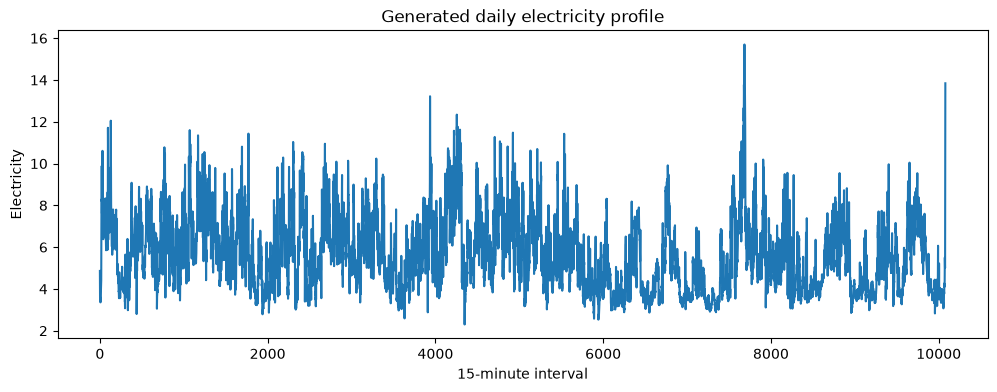

In [47]:
samples = sample1d(
    model,
    sequence_length=10080,
    batch_size=16,
    channels=1
)

final_samples = samples[-1]
generated = final_samples[0, 0]
generated = (
    generated * std.item()
    + mean.item()
)

plt.figure(figsize=(12, 4))
plt.plot(generated)

plt.xlabel("15-minute interval")
plt.ylabel("Electricity")
plt.title("Generated daily electricity profile")

plt.show()

In [48]:
final_samples.shape

(16, 1, 10080)

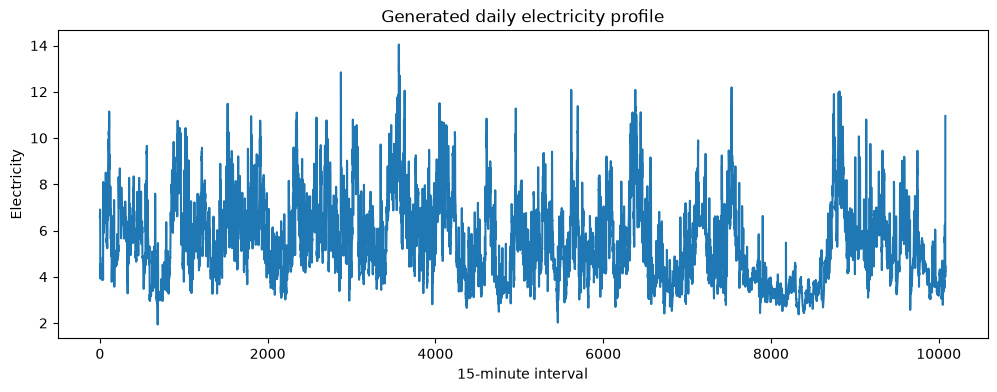

In [49]:
final_samples = samples[-1]
generated = final_samples[5, 0]
generated = (
    generated * std.item()
    + mean.item()
)

plt.figure(figsize=(12, 4))
plt.plot(generated)

plt.xlabel("15-minute interval")
plt.ylabel("Electricity")
plt.title("Generated daily electricity profile")

plt.show()

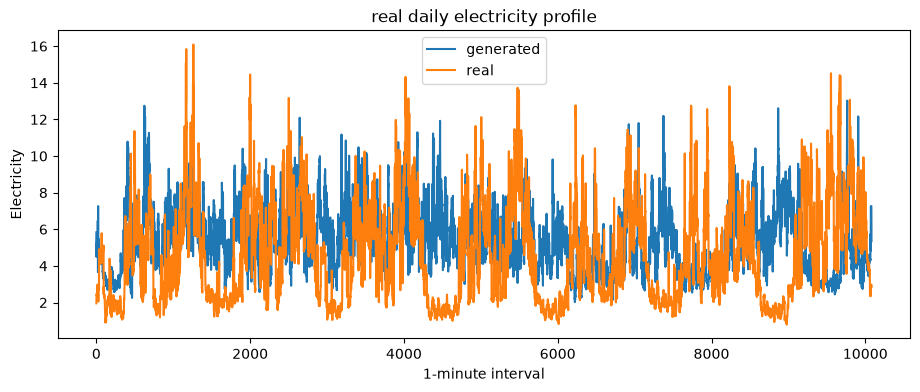

In [51]:
generated = final_samples[8, 0]
generated = (
    generated * std.item()
    + mean.item()
)
real = train_tensor[12].numpy().T
plt.figure(figsize=(11, 4))
plt.plot(generated, label="generated")
plt.plot(real, label="real")
plt.legend()
plt.xlabel("1-minute interval")
plt.ylabel("Electricity")
plt.title("real daily electricity profile");